# Import Necessary Libraries

In [450]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
from sklearn import datasets

# Load First CSV File

In [362]:
df1 = pd.read_csv('/Users/jshn/Desktop/UPTRAIL INTERNSHIP/Week2/Project Files/customer_info.csv')

In [384]:
# Standardize Inconsistent Text Values
# Define Mapping 

loyalty_tier_mapping = {
    'gold': 'Gold',
    'gld': 'Gold',      
    'silver': 'Silver',
    'bronze': 'Bronze'
}


gender_mapping = {
    'male': 'Male',
    'female': 'Female',
    'femle': 'Female',  
    'other': 'Other'
}

# Clean loyalty_tier
df1['loyalty_tier'] = (
    df1['loyalty_tier']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(loyalty_tier_mapping)
    .fillna('Unknown')
)

# Clean gender 
df1['gender'] = (
    df1['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(gender_mapping)
    .fillna('Unknown')
)

print("Unique loyalty_tier values:", df1['loyalty_tier'].unique())
print("Unique gender values:", df1['gender'].unique())

Unique loyalty_tier values: ['Silver' 'Gold' 'Bronze' 'Unknown']
Unique gender values: ['Male' 'Female' 'Other' 'Unknown']


In [368]:
# Convert signup_date to datetime
df1['signup_date'] = pd.to_datetime(df1['signup_date'], errors='coerce')
print(df1.head())

  customer_id                    email signup_date  gender   region  \
0      C00001   shaneramirez@gmail.com  2025-04-26    Male  Central   
1      C00002    jpeterson@bernard.com  2024-11-08  Female  Central   
2      C00003  howardmaurice@yahoo.com  2025-05-15    Male  Central   
3      C00004      yherrera@arnold.org  2025-06-14  Female  Central   
4      C00005  janetwilliams@gmail.com  2025-02-05    Male     West   

  loyalty_tier  
0       Silver  
1         Gold  
2         Gold  
3         Gold  
4       Bronze  


In [289]:
# Loop through columns

for column in df1.columns:
    if df1[column].dtype == 'object':
        # Fill only missing values with 'Unknown'
        df1[column] = df1[column].fillna('Unknown')

In [295]:
# Replace missing datetimes with NaT (Not a Time)
df1['signup_date'] = df1['signup_date'].fillna(pd.NaT)


In [316]:
# Handle Missing Values 
missing_values = df1.isnull().sum()
print("missing_values:\n", missing_values)

missing_values:
 customer_id     0
email           0
signup_date     4
gender          0
region          0
loyalty_tier    0
dtype: int64


# Load Second CSV File 

In [201]:
df2 = pd.read_csv('/Users/jshn/Desktop/UPTRAIL INTERNSHIP/Week2/Project Files/product_info.csv')

In [202]:
# Convert launch date to datetime 
df2['launch_date'] = pd.to_datetime(df2['launch_date'], errors='coerce')
print(df2.head())


  product_id             product_name       category launch_date  base_price  \
0      P0001       Storage Product 39        Storage  2025-11-03       15.88   
1      P0002      Cleaning Product 82       Cleaning  2024-08-18       34.23   
2      P0003      Cleaning Product 85       Cleaning  2024-07-15        7.92   
3      P0004       Kitchen Product 82        Kitchen  2025-04-19        9.13   
4      P0005  Personal Care Product 1  Personal Care  2024-10-20       31.10   

  supplier_code  
0          S339  
1          S974  
2          S745  
3          S589  
4          S559  


/var/folders/8c/f33hbs394s3b3wd1k7v6ywc40000gn/T/ipykernel_95095/3776528261.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['launch_date'] = pd.to_datetime(df2['launch_date'], errors='coerce')


In [203]:
# Handle Missing Values 
missing_values = df2.isnull().sum()
print("missing_values:\n", missing_values)

missing_values:
 product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64


# Load Third CSV File

In [354]:
df3 = pd.read_csv('/Users/jshn/Desktop/UPTRAIL INTERNSHIP/Week2/Project Files/sales_data.csv')

In [355]:
# Convert order_date to datetime 
df3['order_date'] = pd.to_datetime(df3['order_date'], errors='coerce')
print(df3.head())

  order_id customer_id product_id quantity  unit_price order_date  \
0  O966977      C00397      P0022        3       39.25 2025-06-07   
1  O696648      C00236      P0023        5       18.92 2025-06-07   
2  O202644      C00492      P0011        1       29.68 2025-06-07   
3  O501803      C00031      P0003        1       32.76 2025-06-07   
4  O322242      C00495      P0016        1       47.62 2025-06-07   

  delivery_status payment_method   region  discount_applied  
0       Delivered         PayPal  Central              0.00  
1         DELAYED    credit card    North              0.00  
2       delivered  Bank Transfer    North              0.15  
3      Cancelled     Credit Card  Central              0.20  
4         DELAYED    Credit Card     West              0.20  


In [373]:
# Standardize Inconistent Text Values 
# Define mapping 

delivery_status_mapping = {
    'DELAYED': 'Delayed',
    'delivered': 'Delivered',
    'delrd': 'Delivered',
    'cancelled': 'Cancelled',
    'delayed': 'Delayed'
}

payment_method_mapping = {
    'credit card': 'Credit Card',
    'bank transfer': 'Bank Transfer',
    'paypal': 'PayPal'
}

# Clean delivery_status 
df3['delivery_status'] = (
    df3['delivery_status']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(delivery_status_mapping)
)

# Clean payment_method
df3['payment_method'] = (
    df3['payment_method']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(payment_method_mapping)
)

print("Unique delivery_status values:", df3['delivery_status'].unique())
print("Unique payment_method values:", df3['payment_method'].unique())

Unique delivery_status values: ['Delivered' 'Delayed' 'Cancelled' nan]
Unique payment_method values: ['PayPal' 'Credit Card' 'Bank Transfer' nan]


In [343]:
# Replace missing datetimes with NaT (Not a Time)
df3['order_date'] = df3['order_date'].fillna(pd.NaT)

In [344]:
# Fill missing values in numeric column with 0
df3['unit_price'] = df3['unit_price'].fillna(0)

In [348]:
# Handle Missing Values 
missing_values = df3.isnull().sum()
print("missing_values:\n", missing_values)

missing_values:
 order_id              0
customer_id           0
product_id            0
quantity              0
unit_price            0
order_date            0
delivery_status       0
payment_method        0
region                0
discount_applied    517
dtype: int64


In [333]:
# Fill Missing Values 
df3['discount_applied'] = pd.to_numeric(df3['discount_applied'], errors='coerce')

df3.loc[df3['discount_applied'] == 0, 'discount_applied'] = 0.0

df3['discount_applied'] = df3['discount_applied'].astype(float)

print("discount_applied:\n", df3['discount_applied'].head())

discount_applied:
 0    0.00
1    0.00
2    0.15
3    0.20
4    0.20
Name: discount_applied, dtype: float64


In [347]:
# Loop through columns

for column in df3.columns:
    if df3[column].dtype == 'object':
        # Fill only missing values with 'Unknown'
        df3[column] = df3[column].fillna('Unknown')

In [319]:
# Find duplicates

duplicates = df3.duplicated(subset='order_id', keep='first')

print("\nRows marked as duplicates:")
print(df3[duplicates])


Rows marked as duplicates:
     order_id customer_id product_id quantity  unit_price order_date  \
1461  O515400      C00389      P0027        2       22.04 2025-06-07   
2712  O916245      C00070      P0011        3       20.83 2025-06-07   

     delivery_status payment_method region  discount_applied  
1461         Delayed         PayPal  North              0.05  
2712         Delayed  Bank Transfer   West              0.05  


In [334]:
# Drop duplicates 

df3_unique = df3.drop_duplicates(subset='order_id', keep='first')
print("\nDataFrame after dropping duplicates:")
print(df3_unique)


DataFrame after dropping duplicates:
     order_id customer_id product_id quantity  unit_price order_date  \
0     O966977      C00397      P0022        3       39.25 2025-06-07   
1     O696648      C00236      P0023        5       18.92 2025-06-07   
2     O202644      C00492      P0011        1       29.68 2025-06-07   
3     O501803      C00031      P0003        1       32.76 2025-06-07   
4     O322242      C00495      P0016        1       47.62 2025-06-07   
...       ...         ...        ...      ...         ...        ...   
2995  O868860      C00233      P0001        5       43.40 2025-06-07   
2996  O949709      C00246      P0029        4       34.04 2025-06-07   
2997  O763639      C00182      P0026        1       42.34 2025-06-07   
2998  O753958      C00074      P0003        5       35.96 2025-06-07   
2999  O929624      C00405      P0004        3       43.23 2025-06-07   

     delivery_status payment_method   region  discount_applied  
0          Delivered         Pay

# 3. Merged The Data

In [424]:
# Merged The Data Using product_id 

merged_data = pd.merge(df3, df2, on='product_id', how='left')
print(merged_data)

     order_id customer_id product_id quantity  unit_price order_date  \
0     O966977      C00397      P0022        3       39.25 2025-06-07   
1     O696648      C00236      P0023        5       18.92 2025-06-07   
2     O202644      C00492      P0011        1       29.68 2025-06-07   
3     O501803      C00031      P0003        1       32.76 2025-06-07   
4     O322242      C00495      P0016        1       47.62 2025-06-07   
...       ...         ...        ...      ...         ...        ...   
2995  O868860      C00233      P0001        5       43.40 2025-06-07   
2996  O949709      C00246      P0029        4       34.04 2025-06-07   
2997  O763639      C00182      P0026        1       42.34 2025-06-07   
2998  O753958      C00074      P0003        5       35.96 2025-06-07   
2999  O929624      C00405      P0004        3       43.23 2025-06-07   

     delivery_status payment_method   region  discount_applied  \
0          Delivered         PayPal  Central              0.00   
1  

In [379]:
# Final Merge Data

final_merged_data = pd.merge(merged_data, df1, on='customer_id', how='left')
print(final_merged_data)

     order_id customer_id product_id quantity  unit_price order_date  \
0     O966977      C00397      P0022        3       39.25 2025-06-07   
1     O696648      C00236      P0023        5       18.92 2025-06-07   
2     O202644      C00492      P0011        1       29.68 2025-06-07   
3     O501803      C00031      P0003        1       32.76 2025-06-07   
4     O322242      C00495      P0016        1       47.62 2025-06-07   
...       ...         ...        ...      ...         ...        ...   
2999  O868860      C00233      P0001        5       43.40 2025-06-07   
3000  O949709      C00246      P0029        4       34.04 2025-06-07   
3001  O763639      C00182      P0026        1       42.34 2025-06-07   
3002  O753958      C00074      P0003        5       35.96 2025-06-07   
3003  O929624      C00405      P0004        3       43.23 2025-06-07   

     delivery_status payment_method region_x  discount_applied  \
0          Delivered         PayPal  Central              0.00   
1  

In [382]:
# Final merged result 
final_merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          3003 non-null   object        
 1   customer_id       2998 non-null   object        
 2   product_id        2999 non-null   object        
 3   quantity          3001 non-null   object        
 4   unit_price        3003 non-null   float64       
 5   order_date        3001 non-null   datetime64[ns]
 6   delivery_status   3000 non-null   object        
 7   payment_method    3000 non-null   object        
 8   region_x          3004 non-null   object        
 9   discount_applied  2485 non-null   float64       
 10  product_name      2999 non-null   object        
 11  category          2999 non-null   object        
 12  launch_date       2999 non-null   datetime64[ns]
 13  base_price        2999 non-null   float64       
 14  supplier_code     2999 n

In [386]:
# Confirm Merged Successfully

print(final_merged_data.head())

  order_id customer_id product_id quantity  unit_price order_date  \
0  O966977      C00397      P0022        3       39.25 2025-06-07   
1  O696648      C00236      P0023        5       18.92 2025-06-07   
2  O202644      C00492      P0011        1       29.68 2025-06-07   
3  O501803      C00031      P0003        1       32.76 2025-06-07   
4  O322242      C00495      P0016        1       47.62 2025-06-07   

  delivery_status payment_method region_x  discount_applied  \
0       Delivered         PayPal  Central              0.00   
1         Delayed    Credit Card    North              0.00   
2       Delivered  Bank Transfer    North              0.15   
3       Cancelled    Credit Card  Central              0.20   
4         Delayed    Credit Card     West              0.20   

          product_name  category launch_date  base_price supplier_code  \
0  Cleaning Product 86  Cleaning  2024-04-10       19.77          S924   
1  Outdoors Product 32  Outdoors  2025-01-18       36.04  

# 4. Feature Engineering

In [ ]:
# Convert columns to numeric to avoid TypeError when calculating revenue
final_merged_data['quantity'] = pd.to_numeric(final_merged_data['quantity'], errors='coerce')
final_merged_data['unit_price'] = pd.to_numeric(final_merged_data['unit_price'], errors='coerce')
final_merged_data['discount_applied'] = pd.to_numeric(final_merged_data['discount_applied'], errors='coerce')

# Fill NaN with 0 to avoid multiplication issues
final_merged_data[['quantity', 'unit_price', 'discount_applied']] = final_merged_data[['quantity', 'unit_price', 'discount_applied']].fillna(0)

# Now calculate revenue
final_merged_data['revenue'] = (
    final_merged_data['quantity'] *
    final_merged_data['unit_price'] *
    (1 - final_merged_data['discount_applied'])
)


In [437]:
final_merged_data[['quantity', 'unit_price', 'discount_applied']].dtypes


quantity            float64
unit_price          float64
discount_applied    float64
dtype: object

In [397]:
# order_week 
final_merged_data['order_week'] = pd.to_datetime(final_merged_data['order_date'], errors='coerce')
final_merged_data['order_week'] = final_merged_data['order_week'].dt.isocalendar().week

# Price_band
price_bins = [0, 15, 30, float('inf')]
price_labels = ['Low', 'Medium', 'High']
final_merged_data['price_band'] = pd.cut(final_merged_data['unit_price'], bins=price_bins, labels=price_labels, right=False)


# Days_to_order
final_merged_data['launch_date'] = pd.to_datetime(final_merged_data['launch_date'], errors='coerce')
final_merged_data['days_to_order'] = (final_merged_data['order_date'] - final_merged_data['launch_date']).dt.days

# email domain
final_merged_data['email_domain'] = final_merged_data['email'].apply(lambda x: x.split('@')[1] if pd.notnull(x) else 'Unknown')


# Is_late 
final_merged_data['is_late'] = final_merged_data['delivery_status'].map(lambda x: x == "Delayed")

# 5. Summarry Tables

In [440]:
# Weekly Revenue
weekly_revenue = (
    final_merged_data.groupby(['region_y', 'order_week'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['region_y', 'order_week'])
)

In [441]:
# Product Category performance
product_perf = (
    final_merged_data.groupby('product_name')
    .agg({
        'revenue': 'sum',
        'quantity': 'sum',
        'discount_applied': 'mean'
    })
    .reset_index()
)

In [442]:
# Customer Behaviour 

final_merged_data['signup_date'] = pd.to_datetime(final_merged_data['signup_date'], errors='coerce')
final_merged_data['signup_month'] = final_merged_data['signup_date'].dt.to_period('M')

customer_behaviour = (
    final_merged_data.groupby(['loyalty_tier', 'signup_month'])
    .agg({
        'revenue': 'sum',
        'quantity': 'sum',
        'discount_applied': 'mean'
    })
    .rename(columns={'customer_id': 'unique_customers'})
    .reset_index()
)


In [478]:
# Delivery Performance 
delivery_perf = (
    final_merged_data.pivot_table(
        index='region_y',
        columns='price_band',
        values='is_late',
        aggfunc='mean',
        observed=True
    )
    .reset_index()
)

In [446]:
# Preferred Payment Method
payment_pref = (
    final_merged_data.groupby(['loyalty_tier', 'payment_method'])
    .size()
    .reset_index(name='transactions_count')
    .sort_values(['loyalty_tier', 'transactions_count'], ascending=[True, False])
)

# 6. Visual Exploration

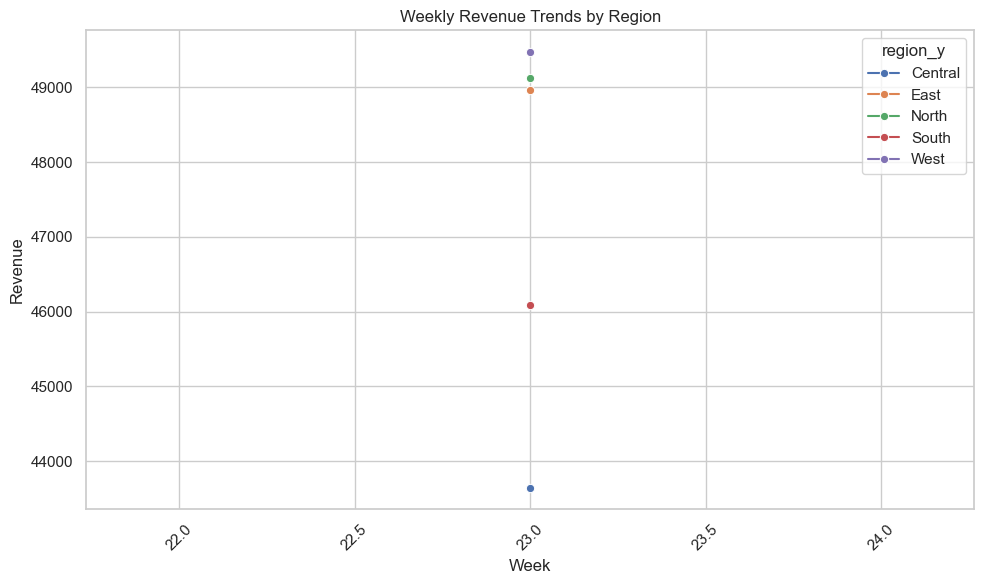

In [ ]:
# Line Plot for Weekly Revenue 

# Style settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Line plot - weekly revenue trends by region
weekly_revenue = (
    final_merged_data.groupby(['region_y', 'order_week'])['revenue']
    .sum()
    .reset_index()
)
sns.lineplot(data=weekly_revenue, x='order_week', y='revenue', hue='region_y', marker="o")
plt.title("Weekly Revenue Trends by Region")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


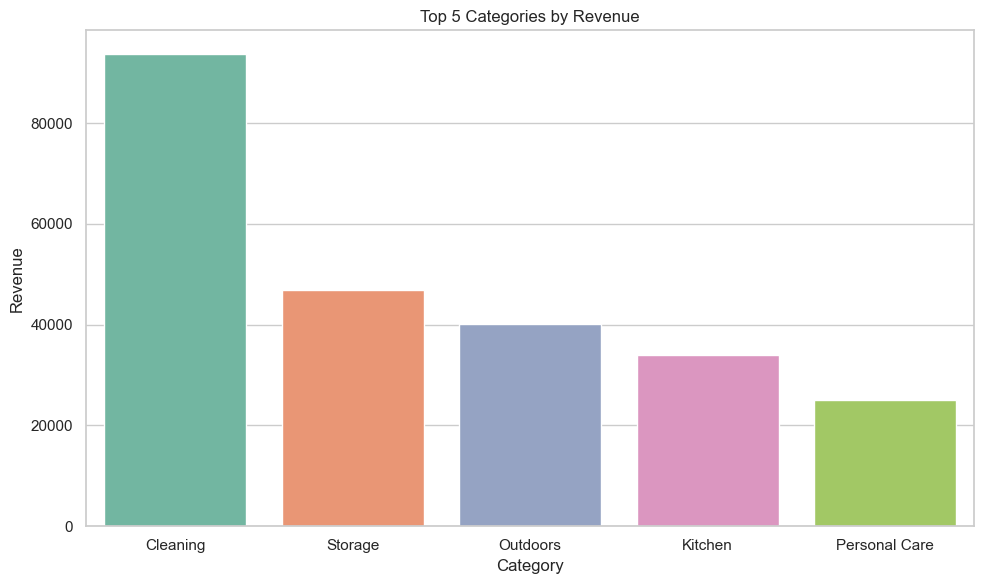

In [465]:
# 2. Bar chart - top 5 categories by revenue
top_categories = final_merged_data.groupby('category')['revenue'].sum().nlargest(5).reset_index()
sns.barplot(data=top_categories, x='category', y='revenue', hue='category', palette="Set2", legend=False)
plt.title("Top 5 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

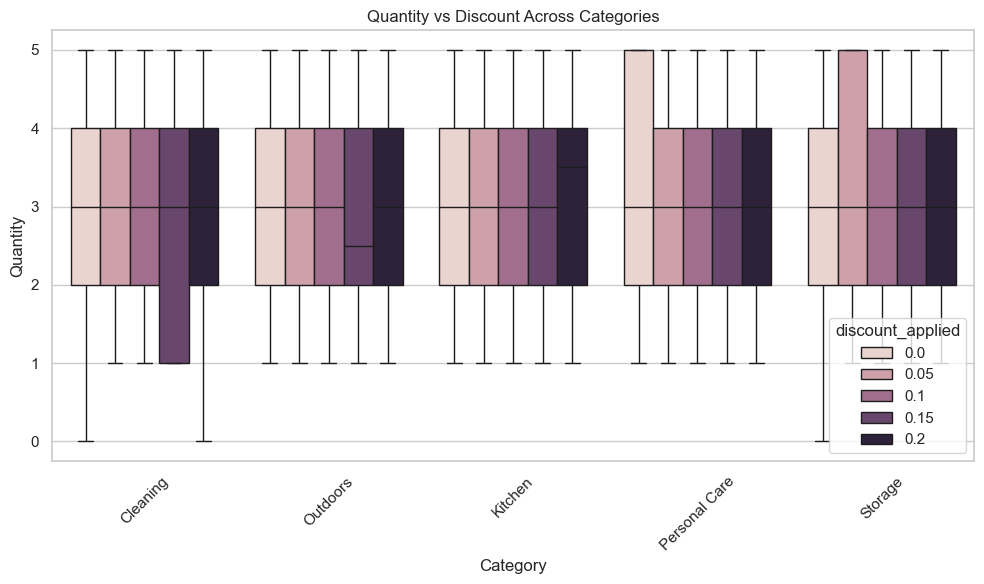

In [466]:
# 3. Boxplot - quantity vs discount across categories
sns.boxplot(data=final_merged_data, x='category', y='quantity', hue='discount_applied')
plt.title("Quantity vs Discount Across Categories")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

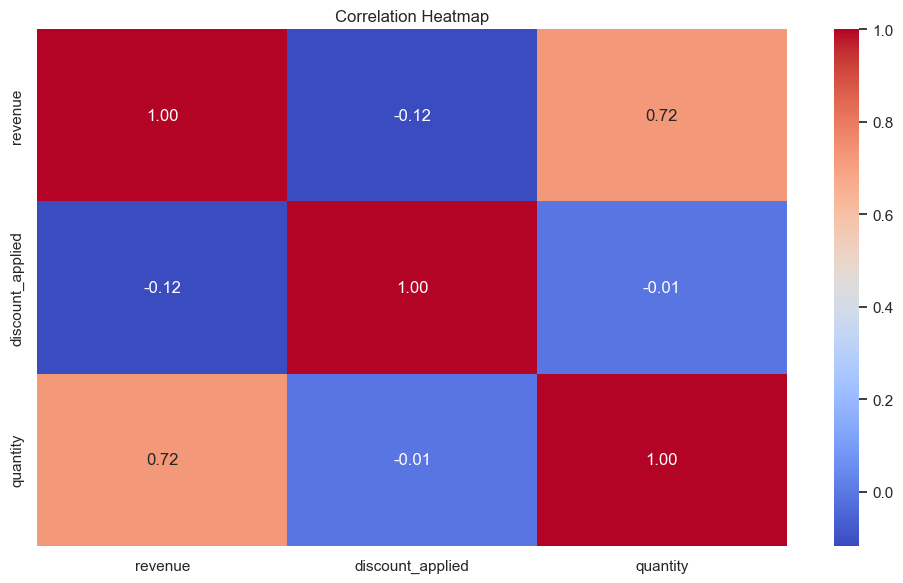

In [469]:
# 4. Heatmap - correlation between revenue, discount, and quantity
corr = final_merged_data[['revenue', 'discount_applied', 'quantity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

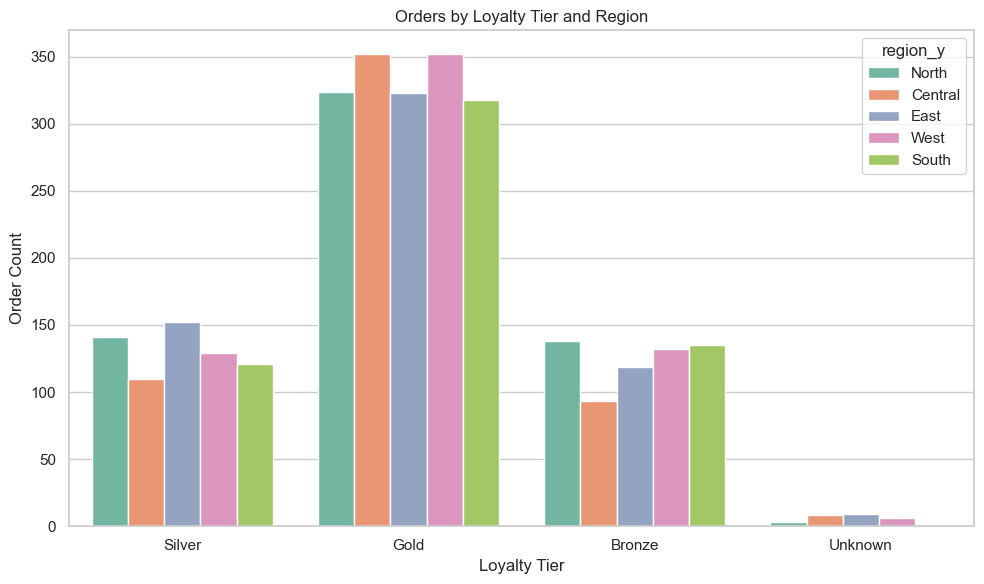

In [471]:
# 5. Countplot - orders by loyalty tier (hue = region)
sns.countplot(data=final_merged_data, x='loyalty_tier', hue='region_y', palette="Set2")
plt.title("Orders by Loyalty Tier and Region")
plt.xlabel("Loyalty Tier")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

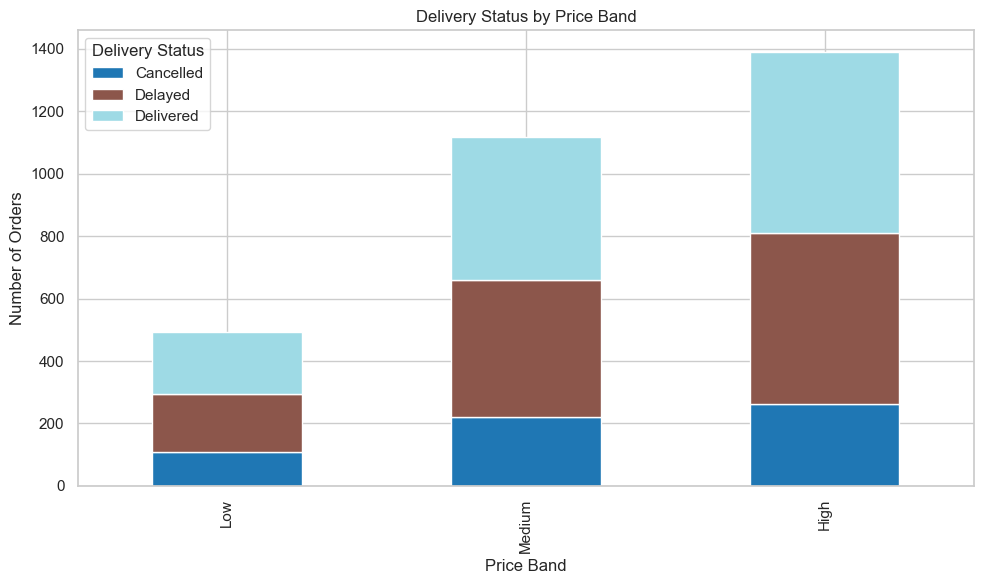

In [477]:
# Stacked Bar Chart for Delivery Status by Price Band
status_counts = final_merged_data.groupby(['price_band', 'delivery_status'], observed=True).size().unstack(fill_value=0)
status_counts.plot(kind='bar', stacked=True, colormap='tab20')
plt.title("Delivery Status by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Orders")
plt.legend(title="Delivery Status")
plt.tight_layout()
plt.show()

# 7. Business Question Answer

In [ ]:
# Product categories Which drive the most revenue, and regions
# Now calculate revenue
final_merged_data['revenue'] = (
    final_merged_data['quantity'] *
    final_merged_data['unit_price'] *
    (1 - final_merged_data['discount_applied'])
)

# Group and sum
category_region_revenue = (
    final_merged_data.groupby(['category', 'region_y'], observed=False)['revenue']
      .sum()
      .reset_index()
      .sort_values('revenue', ascending=False)
)
print(category_region_revenue)

         category region_y     revenue
1        Cleaning     East  20533.6275
4        Cleaning     West  19821.9695
2        Cleaning    North  19693.1075
3        Cleaning    South  17081.0815
0        Cleaning  Central  15739.2890
24        Storage     West  10201.7605
20        Storage  Central   9797.5680
23        Storage    South   9530.4005
21        Storage     East   9017.1015
14       Outdoors     West   8990.5160
12       Outdoors    North   8923.7850
22        Storage    North   7920.0025
10       Outdoors  Central   7470.6555
11       Outdoors     East   7448.8280
7         Kitchen    North   7385.8370
6         Kitchen     East   7210.1390
8         Kitchen    South   7164.7470
5         Kitchen  Central   6639.2535
13       Outdoors    South   6569.0740
18  Personal Care    South   5593.9120
9         Kitchen     West   5471.7590
16  Personal Care     East   5053.9605
19  Personal Care     West   4987.2335
17  Personal Care    North   4851.9200
15  Personal Care  Centra

In [512]:
# Delivering Delay Rate by Region
delay_labels = {'Delayed', 'Late', 'Pending'}
final_merged_data ['is_delay'] = final_merged_data['delivery_status'].isin (delay_labels)

delay_rate = (final_merged_data.groupby ('region_y', observed=True) ['is_delay']
            .mean()
            .sort_values (ascending=False))
counts = final_merged_data.groupby ('region_y', observed=True) ['is_delay'].size()
delay_summary = pd. DataFrame ({'delay_rate': delay_rate, 'n_orders': counts})

print ("Delay Rate by Region: \n", delay_summary. sort_values ('delay_rate', ascending=False))

Delay Rate by Region: 
           delay_rate  n_orders
region_y                      
West        0.410339       619
Central     0.406750       563
South       0.402439       574
North       0.391089       606
East        0.349917       603


In [ ]:
# Do customer signup patterns influence purchasing activity

# Customer-level aggregates
cust = (final_merged_data.groupby( 'customer_id', observed=True)
        .agg( 
            signup=('signup_date', 'min'), 
            first_order=('order_date', 'min'),
            orders=('order_id', 'nunique'),
            revenue=('revenue', 'sum')
)
.dropna (subset= ['signup']))


# Cohort by signup month
cust['signup_month'] = cust['signup'].dt.to_period('M').dt.to_timestamp()
cohort_stats = (cust.groupby( 'signup_month', observed=True)
                .agg (customers=( 'orders','size'),
                avg_orders=('orders', 'mean'),
                median_rev=('revenue', 'median'), 
                conv_rate=('first_order', lambda s: s.notna ().mean()))
                .reset_index()
                .sort_values ('signup_month'))
print ("Signup Cohort KPIs: \n", cohort_stats.head(12))

cust ['days_to_first'] = (cust['first_order'] - cust ['signup']) .dt. days
rel = cust[['days_to_first', 'revenue']].dropna()
from scipy.stats import spearmanr
rho, p = spearmanr(rel['days_to_first'], rel['revenue'])

print(f"In Spearman (days_to_first, revenue) = {rho:.3f}, p={p:.3g}")


Signup Cohort KPIs: 
    signup_month  customers  avg_orders  median_rev  conv_rate
0    2024-01-01          8    6.375000   575.36950        1.0
1    2024-02-01          9    4.888889   277.54800        1.0
2    2024-03-01          8    5.625000   515.40725        1.0
3    2024-04-01          7    4.142857   388.95000        1.0
4    2024-05-01          6    4.333333   303.19925        1.0
5    2024-06-01         13    5.846154   486.99000        1.0
6    2024-07-01         31    5.677419   437.70150        1.0
7    2024-08-01         34    5.852941   471.99025        1.0
8    2024-09-01         38    6.157895   496.48075        1.0
9    2024-10-01         44    6.000000   440.13200        1.0
10   2024-11-01         33    6.393939   446.86700        1.0
11   2024-12-01         35    5.771429   405.88100        1.0
In Spearman (days_to_first, revenue) = -0.028, p=0.534
